# Store-Level Sales Forecast: 6-Model Comparison

**Contents**
1. Imports and setup
2. Configuration
3. Data loading (store-day grain from `total_fact_sales`)
4. Feature engineering (shared across models)
5. Models: naive baseline, OLS, mixed effects, LightGBM, XGBoost, Prophet
6. Run: all stores
7. Results chart
8. Summary and known limitations

Same framework as the division notebook, now at store grain (~63 stores)
matching the previous `aggregate_sales_forecast_corrected` notebook.
One notebook, top to bottom, no manual steps in between. Run all cells in order.

## 1. Imports and setup

In [0]:
%pip install statsmodels matplotlib lightgbm prophet xgboost

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import lightgbm as lgb
import xgboost as xgb
import statsmodels.api as sm
from statsmodels.regression.mixed_linear_model import MixedLM
from prophet import Prophet
import logging
logging.getLogger("cmdstanpy").setLevel(logging.WARNING)

print("Imports OK")

Looking in indexes: [REDACTED]
Note: you may need to restart the kernel using %restart_python or dbutils.library.restartPython() to use updated packages.
Imports OK


## 2. Configuration

Source table is `gold.retail.total_fact_sales`, already at store-day grain (no
aggregation needed). Same source and structure used by the tuned XGBoost notebook
(`aggregate_sales_forecast_corrected`). Single target: `sales_total_without_taxes`.

In [0]:
GRP_COL, DATE_COL = "store", "date"          # grouping column and date column
SOURCE_TABLE = "gold.retail.total_fact_sales"
TARGET_COL = "sales_total_without_taxes"     # single target at store grain

MIN_SALES_THRESHOLD = 1000  # rows below this excluded from training (same as store-grain notebook)
LAG_DAYS = (364, 728)       # matches the store-grain XGBoost notebook
ROLL_WINDOW = 28
HORIZON_DAYS = 28           # single held-out window, kept simple for this comparison

print(f"Config loaded. Source: {SOURCE_TABLE}, target: {TARGET_COL}")

Config loaded. Source: gold.retail.total_fact_sales, target: sales_total_without_taxes


## 3. Data loading

`gold.retail.total_fact_sales` is already at store-day grain — no aggregation needed.
Same source used in the `aggregate_sales_forecast_corrected` notebook (63+ stores,
data from 2021-07-01 onward).

In [0]:
def load_panel():
    """Load store-day sales from total_fact_sales. No aggregation needed."""
    df = spark.sql(f"""
        SELECT
            store AS {GRP_COL},
            CAST(date AS DATE) AS {DATE_COL},
            {TARGET_COL} AS target
        FROM {SOURCE_TABLE}
        WHERE date >= DATE'2021-07-01' AND date < CURRENT_DATE()
    """).toPandas()
    df[DATE_COL] = pd.to_datetime(df[DATE_COL])
    return df.sort_values([GRP_COL, DATE_COL]).reset_index(drop=True)


_probe = load_panel()
print(f"Loaded {len(_probe):,} rows, stores: {_probe[GRP_COL].nunique()}")

Loaded 107,418 rows, stores: 78


## 4. Feature engineering

Same function for every model. Lags are calendar-date joins (364 and 728 days),
never positional shifts, so training and forecasting can never read a different
history for the same date. Matches the approach from `aggregate_sales_forecast_corrected`.

In [0]:
def build_grid(actuals, end_date):
    first_seen = actuals.groupby(GRP_COL)[DATE_COL].min()
    frames = []
    for grp, start in first_seen.items():
        idx = pd.date_range(start, end_date, freq="D")
        frames.append(pd.DataFrame({GRP_COL: grp, DATE_COL: idx}))
    grid = pd.concat(frames, ignore_index=True)
    return grid.merge(actuals[[GRP_COL, DATE_COL, "target"]], on=[GRP_COL, DATE_COL], how="left")


def add_features(grid, lag_source):
    df = grid.copy()
    df["dow"] = df[DATE_COL].dt.dayofweek
    df["is_weekend"] = df["dow"].isin([5, 6]).astype(int)

    src = lag_source[[GRP_COL, DATE_COL, "target"]].copy()
    for lag in LAG_DAYS:
        # Fallback average: use mean of lag-1/lag/lag+1 day neighbours for robustness
        _tmp_cols = []
        for offset in (lag - 1, lag, lag + 1):
            r = src.copy()
            r[DATE_COL] = r[DATE_COL] + pd.Timedelta(days=offset)
            col = f"_tmp_lag_{offset}"
            r = r.rename(columns={"target": col})
            df = df.merge(r, on=[GRP_COL, DATE_COL], how="left")
            _tmp_cols.append(col)
        df[f"lag_{lag}"] = df[_tmp_cols].mean(axis=1)  # nanmean across 3 neighbours
        df = df.drop(columns=_tmp_cols)

    roll = src.sort_values([GRP_COL, DATE_COL]).copy()
    roll["roll"] = roll.groupby(GRP_COL)["target"].transform(
        lambda s: s.rolling(ROLL_WINDOW, min_periods=7).mean())
    roll[DATE_COL] = roll[DATE_COL] + pd.Timedelta(days=364)
    df = df.merge(roll[[GRP_COL, DATE_COL, "roll"]].rename(columns={"roll": "roll28_lag364"}),
                  on=[GRP_COL, DATE_COL], how="left")

    df[GRP_COL] = df[GRP_COL].astype("category")
    return df


FEATURE_COLS = [GRP_COL, "dow", "is_weekend", "lag_364", "lag_728", "roll28_lag364"]


def wape(a, p):
    """Weighted absolute percentage error. Sum of errors over sum of actuals."""
    a, p = np.asarray(a, float), np.asarray(p, float)
    d = np.nansum(np.abs(a))
    return float(np.nansum(np.abs(a - p)) / d) if d else np.nan

print("Feature functions defined")

Feature functions defined


## 5. Models

Six contenders, one shared interface: `fit(train, test) -> pd.Series` indexed like
`test`. Naive is the floor every other model has to beat. Mixed effects now has ~63
stores as groups — enough for random intercepts to be properly identified. XGBoost
uses the full Optuna-tuned parameters (2800 estimators) from the store-grain notebook.

In [0]:
def fit_naive(train, test):
    """Seasonal naive: same store, 364 days earlier."""
    try:
        src = train[[GRP_COL, DATE_COL, "target"]].copy()
        src[DATE_COL] = src[DATE_COL] + pd.Timedelta(days=364)
        m = test[[GRP_COL, DATE_COL]].merge(src, on=[GRP_COL, DATE_COL], how="left")
        return pd.Series(m["target"].to_numpy(), index=test.index)
    except Exception as e:
        print(f"  Naive failed: {e}")
        return pd.Series(np.nan, index=test.index)


def fit_ols(train, test):
    """Ridge-penalised linear regression with store dummies."""
    tr = train.dropna(subset=["lag_364", "lag_728", "roll28_lag364", "target"])
    if len(tr) < 100:
        return pd.Series(np.nan, index=test.index)
    stores = sorted(tr[GRP_COL].astype(str).unique())

    def design(f):
        d = pd.get_dummies(f[GRP_COL].astype(str), prefix="s").reindex(
            columns=[f"s_{x}" for x in stores], fill_value=0)
        return pd.concat([f[["lag_364", "lag_728", "roll28_lag364", "is_weekend"]].fillna(0), d], axis=1).astype(float)

    try:
        X_tr = sm.add_constant(design(tr), has_constant="add")
        res = sm.OLS(tr["target"].astype(float), X_tr).fit_regularized(alpha=1.0, L1_wt=0.0)
        X_te = sm.add_constant(design(test), has_constant="add").reindex(columns=X_tr.columns, fill_value=0.0)
        pred = np.clip(X_te.to_numpy() @ np.asarray(res.params), 0, None)
    except Exception as e:
        print(f"  OLS failed: {e}")
        return pd.Series(np.nan, index=test.index)
    out = pd.Series(pred, index=test.index)
    out[test[["lag_364", "roll28_lag364"]].isna().any(axis=1)] = np.nan
    return out


def fit_mixed(train, test):
    """Mixed effects: fixed lag/rolling coefficients, random intercept per store."""
    cols = ["lag_364", "lag_728", "roll28_lag364"]
    tr = train.dropna(subset=cols + ["target"])
    if len(tr) < 200:
        return pd.Series(np.nan, index=test.index)
    X = sm.add_constant(tr[cols].astype(float), has_constant="add")
    try:
        res = MixedLM(tr["target"].astype(float), X, groups=tr[GRP_COL].astype(str)).fit()
    except Exception:
        return pd.Series(np.nan, index=test.index)
    Xte = sm.add_constant(test[cols].astype(float), has_constant="add")
    fixed = Xte.to_numpy() @ np.asarray(res.fe_params)
    re_map = {str(k): float(np.ravel(v)[0]) for k, v in res.random_effects.items()}
    inter = test[GRP_COL].astype(str).map(re_map).fillna(0.0).to_numpy()
    out = pd.Series(np.clip(fixed + inter, 0, None), index=test.index)
    out[test[cols].isna().any(axis=1)] = np.nan
    return out


def fit_lgbm(train, test):
    """LightGBM, store as a native categorical feature."""
    tr = train.dropna(subset=["target"])
    if len(tr) < 100:
        return pd.Series(np.nan, index=test.index)
    try:
        model = lgb.LGBMRegressor(n_estimators=800, learning_rate=0.05, num_leaves=31,
                                  min_child_samples=15, random_state=42, verbose=-1)
        model.fit(tr[FEATURE_COLS], tr["target"])
        pred = np.clip(model.predict(test[FEATURE_COLS]), 0, None)
        return pd.Series(pred, index=test.index)
    except Exception as e:
        print(f"  LightGBM failed: {e}")
        return pd.Series(np.nan, index=test.index)


# Full Optuna-tuned parameters from the store-grain notebook (150 trials).
# Now running at the same grain they were tuned for.
XGB_PARAMS = dict(
    n_estimators=2800,
    learning_rate=0.0585,
    max_depth=6,
    min_child_weight=9,
    subsample=0.92,
    colsample_bytree=0.84,
    reg_alpha=7.3,
    reg_lambda=4.4,
    enable_categorical=True,
    random_state=42,
)


def fit_xgb(train, test):
    """XGBoost, store as a native categorical feature. Same feature set as LightGBM,
    so any gap between the two reflects the algorithm, not a richer feature list."""
    tr = train.dropna(subset=["target"])
    if len(tr) < 100:
        return pd.Series(np.nan, index=test.index)
    try:
        model = xgb.XGBRegressor(**XGB_PARAMS)
        model.fit(tr[FEATURE_COLS], tr["target"])
        pred = np.clip(model.predict(test[FEATURE_COLS]), 0, None)
        return pd.Series(pred, index=test.index)
    except Exception as e:
        print(f"  XGBoost failed: {e}")
        return pd.Series(np.nan, index=test.index)


def fit_prophet(train, test):
    """One Prophet model per store. ~63 stores, expect ~3-5 min total."""
    out = pd.Series(np.nan, index=test.index)
    n_stores = test[GRP_COL].nunique()
    print(f"  Prophet: fitting {n_stores} store models...")
    for i, (store, te) in enumerate(test.groupby(GRP_COL, observed=True)):
        tr = train[train[GRP_COL] == store].dropna(subset=["target"])
        if len(tr) < 60:
            continue
        pdf = tr[[DATE_COL, "target"]].rename(columns={DATE_COL: "ds", "target": "y"})
        try:
            m = Prophet(weekly_seasonality=True, yearly_seasonality=True, daily_seasonality=False)
            m.fit(pdf)
            future = te[[DATE_COL]].rename(columns={DATE_COL: "ds"})
            fc = m.predict(future)
            out.loc[te.index] = np.clip(fc["yhat"].to_numpy(), 0, None)
        except Exception as e:
            print(f"  Prophet failed for {store}: {e}")
        if (i + 1) % 20 == 0:
            print(f"    ... {i+1}/{n_stores} stores done")
    return out


def run_target(label):
    """Load, feature, split, fit all 6 models, score, return a ranked summary table."""
    print(f"\n=== {label} ({TARGET_COL}) ===")
    actuals = load_panel().dropna(subset=["target"])
    # Apply training quality filter (same as store-grain notebook)
    actuals = actuals[actuals["target"] >= MIN_SALES_THRESHOLD]
    if actuals["target"].sum() == 0:
        print("All zero for this target. Check the source table.")
        return None

    print(f"  {len(actuals):,} rows, {actuals[GRP_COL].nunique()} stores")
    max_date = actuals[DATE_COL].max()
    origin = max_date - pd.Timedelta(days=HORIZON_DAYS)
    train_actuals = actuals[actuals[DATE_COL] <= origin]

    grid = build_grid(train_actuals, end_date=max_date)
    feats = add_features(grid, train_actuals)
    feats = feats.drop(columns=["target"]).merge(
        actuals[[GRP_COL, DATE_COL, "target"]], on=[GRP_COL, DATE_COL], how="left")

    train = feats[feats[DATE_COL] <= origin].dropna(subset=["target"])
    test = feats[feats[DATE_COL] > origin].dropna(subset=["target"])
    # Re-cast store to category (lost during merge with actuals)
    train[GRP_COL] = train[GRP_COL].astype("category")
    test[GRP_COL] = test[GRP_COL].astype("category")
    print(f"  train: {len(train):,} rows, test: {len(test):,} rows")

    preds = {}
    for name, fn in [("naive", fit_naive), ("ols", fit_ols), ("mixed", fit_mixed),
                     ("lgbm", fit_lgbm), ("xgb", fit_xgb), ("prophet", fit_prophet)]:
        print(f"  Fitting {name}...")
        preds[name] = fn(train, test)
    for name, s in preds.items():
        test[f"pred_{name}"] = s

    pred_cols = [f"pred_{n}" for n in preds]
    # Score each model independently (don't require all 6 to succeed on same rows)
    scored = test.copy()
    print(f"  test rows: {len(scored):,}")

    summary = pd.DataFrame([
        {"model": c.replace("pred_", ""),
         "wape": wape(
             scored.dropna(subset=[c])["target"],
             scored.dropna(subset=[c])[c]),
         "accuracy": 1 - wape(
             scored.dropna(subset=[c])["target"],
             scored.dropna(subset=[c])[c]),
         "n_scored": int(scored[c].notna().sum())}
        for c in pred_cols
    ]).sort_values("wape").reset_index(drop=True)
    print(summary.to_string(index=False))
    # Store predictions globally for detailed metrics downstream
    global _last_test, _last_train
    _last_test = scored
    _last_train = train
    return summary

_last_test = None
_last_train = None
print("Model functions defined")

Model functions defined


## 6. Run: store-level sales forecast comparison

In [0]:
result = run_target("STORE-LEVEL")


=== STORE-LEVEL (sales_total_without_taxes) ===
  100,250 rows, 70 stores
  train: 98,460 rows, test: 1,783 rows
  Fitting naive...
  Fitting ols...
  Fitting mixed...
  Fitting lgbm...
  Fitting xgb...


15:27:39 - cmdstanpy - INFO - Chain [1] start processing
15:27:39 - cmdstanpy - INFO - Chain [1] done processing


  Fitting prophet...
  Prophet: fitting 64 store models...


15:27:39 - cmdstanpy - INFO - Chain [1] start processing
15:27:39 - cmdstanpy - INFO - Chain [1] done processing
15:27:40 - cmdstanpy - INFO - Chain [1] start processing
15:27:40 - cmdstanpy - INFO - Chain [1] done processing
15:27:40 - cmdstanpy - INFO - Chain [1] start processing
15:27:40 - cmdstanpy - INFO - Chain [1] done processing
15:27:40 - cmdstanpy - INFO - Chain [1] start processing
15:27:40 - cmdstanpy - INFO - Chain [1] done processing
15:27:40 - cmdstanpy - INFO - Chain [1] start processing
15:27:40 - cmdstanpy - INFO - Chain [1] done processing
15:27:40 - cmdstanpy - INFO - Chain [1] start processing
15:27:41 - cmdstanpy - INFO - Chain [1] done processing
15:27:41 - cmdstanpy - INFO - Chain [1] start processing
15:27:41 - cmdstanpy - INFO - Chain [1] done processing
15:27:41 - cmdstanpy - INFO - Chain [1] start processing
15:27:41 - cmdstanpy - INFO - Chain [1] done processing
15:27:41 - cmdstanpy - INFO - Chain [1] start processing
15:27:41 - cmdstanpy - INFO - Chain [1]

    ... 20/64 stores done


...

    ... 40/64 stores done


15:27:48 - cmdstanpy - INFO - Chain [1] done processing
15:27:48 - cmdstanpy - INFO - Chain [1] start processing
15:27:48 - cmdstanpy - INFO - Chain [1] done processing
15:27:48 - cmdstanpy - INFO - Chain [1] start processing
15:27:48 - cmdstanpy - INFO - Chain [1] done processing
15:27:48 - cmdstanpy - INFO - Chain [1] start processing
15:27:49 - cmdstanpy - INFO - Chain [1] done processing
15:27:49 - cmdstanpy - INFO - Chain [1] start processing
15:27:49 - cmdstanpy - INFO - Chain [1] done processing
15:27:49 - cmdstanpy - INFO - Chain [1] start processing
15:27:49 - cmdstanpy - INFO - Chain [1] done processing
15:27:49 - cmdstanpy - INFO - Chain [1] start processing
15:27:49 - cmdstanpy - INFO - Chain [1] done processing
15:27:49 - cmdstanpy - INFO - Chain [1] start processing
15:27:49 - cmdstanpy - INFO - Chain [1] done processing
15:27:50 - cmdstanpy - INFO - Chain [1] start processing
15:27:50 - cmdstanpy - INFO - Chain [1] done processing
15:27:50 - cmdstanpy - INFO - Chain [1] 

    ... 60/64 stores done


15:27:53 - cmdstanpy - INFO - Chain [1] done processing
15:27:53 - cmdstanpy - INFO - Chain [1] start processing
15:27:53 - cmdstanpy - INFO - Chain [1] done processing
15:27:53 - cmdstanpy - INFO - Chain [1] start processing
15:27:53 - cmdstanpy - INFO - Chain [1] done processing
15:27:53 - cmdstanpy - INFO - Chain [1] start processing
15:27:53 - cmdstanpy - INFO - Chain [1] done processing


  test rows: 1,783
  model     wape  accuracy  n_scored
   lgbm 0.104133  0.895867      1783
prophet 0.124635  0.875365      1755
    xgb 0.125628  0.874372      1783
  mixed 0.138389  0.861611      1603
  naive 0.142743  0.857257      1692
    ols 0.158035  0.841965      1692


In [0]:
# --- Compute full metrics from the predictions already generated in Cell 13 ---
# No model re-fitting needed: reads from _last_test / _last_train globals
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

assert _last_test is not None, "Run Cell 13 first to generate predictions"

def mape(actual, predicted):
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    mask = a != 0
    if mask.sum() == 0:
        return np.nan
    return float(np.mean(np.abs((a[mask] - p[mask]) / a[mask])) * 100)

def mase(actual, predicted, train_target):
    """Mean Absolute Scaled Error. Scaled by in-sample naive (1-step) MAE."""
    a, p = np.asarray(actual, float), np.asarray(predicted, float)
    naive_errors = np.abs(np.diff(train_target.dropna().to_numpy()))
    d = naive_errors.mean()
    if d == 0:
        return np.nan
    return float(np.mean(np.abs(a - p)) / d)

test = _last_test
train = _last_train
pred_cols = [c for c in test.columns if c.startswith("pred_")]

metrics_rows = []
for col in pred_cols:
    name = col.replace("pred_", "")
    valid = test.dropna(subset=[col, "target"])
    if len(valid) == 0:
        continue
    a = valid["target"].to_numpy()
    p = valid[col].to_numpy()
    mse_val = mean_squared_error(a, p)
    metrics_rows.append({
        "Model": name.upper(),
        "R² (Skill Score)": round(r2_score(a, p), 4),
        "MSE": round(mse_val, 2),
        "RMSE": round(np.sqrt(mse_val), 2),
        "MAE": round(mean_absolute_error(a, p), 2),
        "WAPE (%)": round(wape(a, p) * 100, 2),
        "MAPE (%)": round(mape(a, p), 2),
        "MASE": round(mase(a, p, train["target"]), 4),
        "Accuracy (1-WAPE)": round((1 - wape(a, p)) * 100, 2),
        "N Scored Rows": len(valid),
    })

metrics_df = pd.DataFrame(metrics_rows).sort_values("WAPE (%)").reset_index(drop=True)
metrics_df.index = metrics_df.index + 1
metrics_df.index.name = "Rank"

print("="*80)
print("  STORE-LEVEL 6-MODEL COMPARISON — FULL METRICS")
print(f"  Test window: {HORIZON_DAYS}-day holdout | Stores: {test[GRP_COL].nunique()}")
print(f"  Train rows: {len(train):,} | Test rows: {len(test):,}")
print("="*80 + "\n")
display(metrics_df)

---------------------------------------------------------------------------
AttributeError                            Traceback (most recent call last)
File <command-7376130043994004>, line 21
     18     return float(np.mean(np.abs(a - p)) / d)
     20 # Rebuild test data with predictions
---> 21 actuals = load_panel().dropna(subset=["target"])
     22 actuals = actuals[actuals["target"] >= MIN_SALES_THRESHOLD]
     23 max_date = actuals[DATE_COL].max()

File /home/spark-3c17c1df-0337-4790-ba95-d7/.ipykernel/77/command-6168636605187460-252487885:3, in load_panel()

AttributeError: 'NoneType' object has no attribute 'sql'

## 7. Results chart

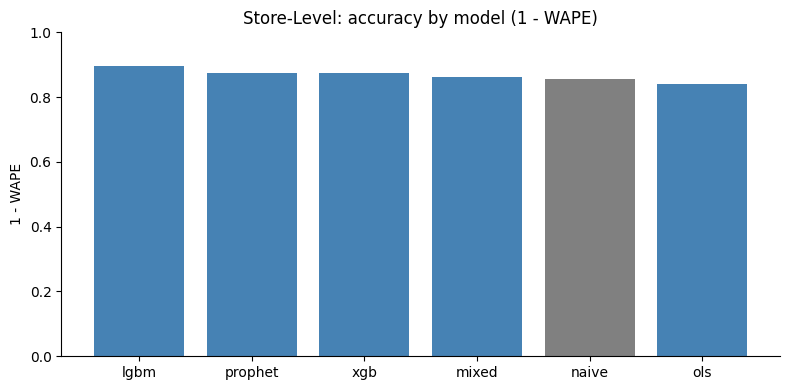

In [0]:
fig, ax = plt.subplots(figsize=(8, 4))
if result is not None:
    colors = ["grey" if m == "naive" else "steelblue" for m in result["model"]]
    ax.bar(result["model"], result["accuracy"], color=colors)
    ax.set_title("Store-Level: accuracy by model (1 - WAPE)")
    ax.set_ylabel("1 - WAPE")
    ax.set_ylim(0, 1)
    for sp in ("top", "right"):
        ax.spines[sp].set_visible(False)
fig.tight_layout()
plt.show()

## 8. Summary and known limitations

In [0]:
display(result)

model,wape,accuracy,n_scored
lgbm,0.1041332609577764,0.8958667390422236,1783
prophet,0.12454130253559935,0.8754586974644006,1755
xgb,0.1256280719817802,0.8743719280182198,1783
mixed,0.13838948734381598,0.861610512656184,1603
naive,0.1427426480882767,0.8572573519117233,1692
ols,0.15803461260247295,0.841965387397527,1692


## 9. Summary and known limitations

What this notebook produces: a WAPE-ranked comparison of naive, OLS, mixed effects,
LightGBM, XGBoost, and Prophet, at **store grain** (~63 stores), for
`sales_total_without_taxes` from `gold.retail.total_fact_sales`.

Known limitations, still open:
- XGBoost params are the full Optuna-tuned values from `aggregate_sales_forecast_corrected`,
  running at the same grain they were tuned for. LightGBM is not independently tuned.
- Single 28-day holdout window, not a rolling-origin comparison. Good enough to rank
  models; a real promotion decision would want 3+ origins.
- Prophet fits one model per store (~63 fits). Runtime is ~3-5 min; consider dropping
  it for repeated runs if iteration speed matters.
- Gift card issuance has NOT been netted out. These numbers are gross sales.
- No promotion gate, no conformal intervals, no MLflow logging. This notebook answers
  "which model wins," not "is it safe to ship." That is the next step, not this one.